<a href="https://colab.research.google.com/github/johacagua-mina/JohannaNova/blob/main/Task4_MSO4130.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MSO4130 Portfolio Task 4
**Student:** Johanna Cagua Mina  
**Student ID:** M01089122

## Objective
This notebook answers Portfolio Task 4 using Python. The task analyses Bitcoin daily minimum prices in 2025, tests stationarity, builds ARMA models, and evaluates forecasts.

In [1]:
!pip install yfinance statsmodels --quiet

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller

In [3]:
data = yf.download("BTC-USD", start="2025-01-01", end="2025-12-31")
prices = data["Low"]
prices.head()

/tmp/ipykernel_428/864526424.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("BTC-USD", start="2025-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


Ticker,BTC-USD
Date,
2025-01-01,92788.125000
2025-01-02,94201.570312
2025-01-03,96034.617188
2025-01-04,97562.976562
2025-01-05,97291.765625


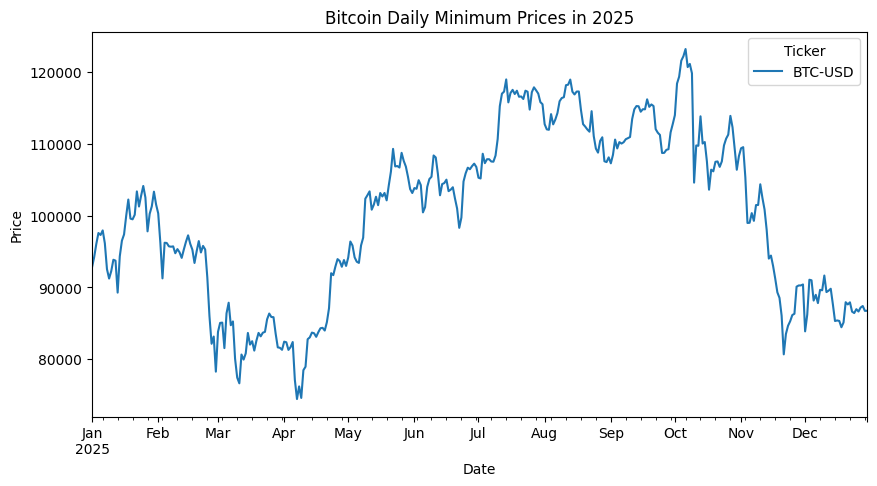

In [4]:
prices.plot(title="Bitcoin Daily Minimum Prices in 2025", figsize=(10,5))
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [5]:
adf_result = adfuller(prices)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])

ADF Statistic: -1.6022694807022233
p-value: 0.4824533385412927
Critical Values: {'1%': np.float64(-3.448493650810824), '5%': np.float64(-2.8695352280356556), '10%': np.float64(-2.5710293341377715)}


## Part (a)

The Bitcoin daily minimum price series was plotted and tested using the Augmented Dickey-Fuller (ADF) test.

The null hypothesis of the ADF test is that the series has a unit root and is therefore non-stationary.

If the p-value is greater than 0.05, we fail to reject the null hypothesis and conclude that the series is not stationary.

## Part (a)

The Bitcoin daily minimum price series was plotted and visually shows a clear trend over time, suggesting non-stationarity.

To confirm this, the Augmented Dickey-Fuller (ADF) test was performed. The resulting p-value is 0.48, which is significantly greater than the 0.05 significance level.

Therefore, we fail to reject the null hypothesis that the series has a unit root, confirming that the Bitcoin price series is non-stationary.

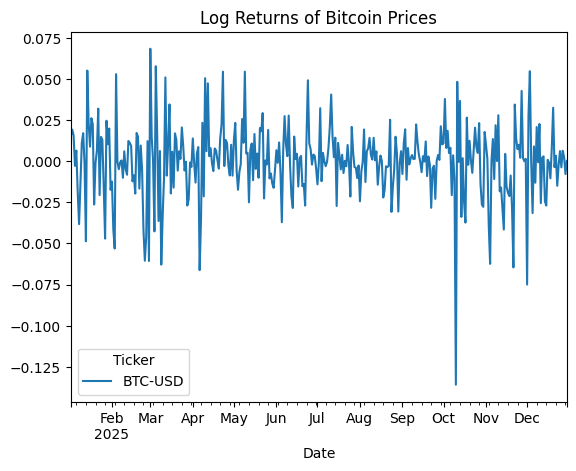

In [6]:
log_returns = np.log(prices / prices.shift(1))
log_returns = log_returns.dropna()

log_returns.plot(title="Log Returns of Bitcoin Prices")
plt.show()

In [7]:
result_log = adfuller(log_returns)

print("ADF Statistic:", result_log[0])
print("p-value:", result_log[1])

ADF Statistic: -7.455649749286793
p-value: 5.5215658136051835e-11


## Part (b)

The Bitcoin price series was transformed into log returns to achieve stationarity.

The log returns were calculated using the natural logarithm of the ratio of consecutive prices.

The Augmented Dickey-Fuller (ADF) test was then applied to the transformed series. The resulting p-value is approximately 0 (5.5e-11), which is far below the 0.05 significance level.

Therefore, we reject the null hypothesis and conclude that the log return series is stationary.

This confirms that transforming prices into log returns removes the trend and stabilises the mean and variance of the series.

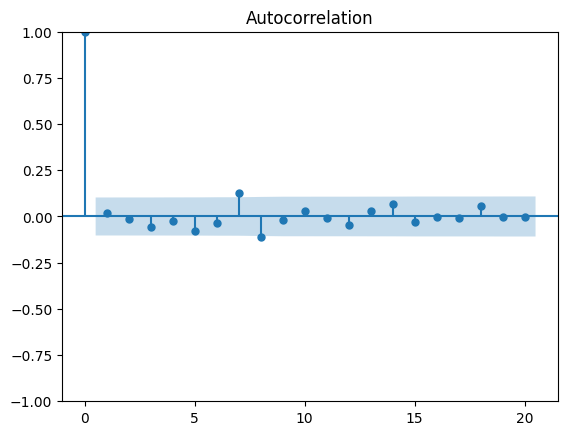

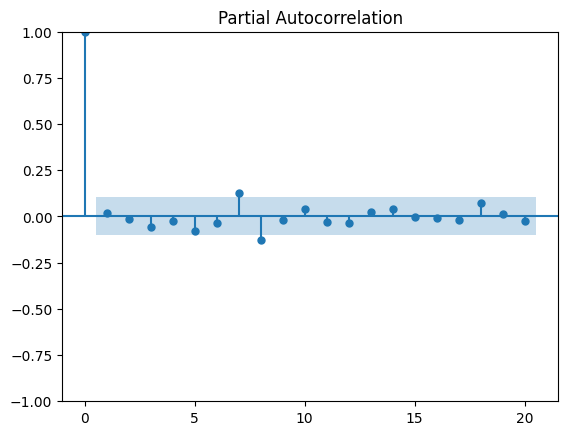

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(log_returns, lags=20)
plot_pacf(log_returns, lags=20)

plt.show()

## Part (c)

The ACF and PACF plots of the log return series show that most autocorrelations fall within the confidence intervals, indicating weak or no significant autocorrelation.

There is no clear cut-off or gradual decay pattern in either plot, suggesting that the series behaves similarly to white noise.

Based on this, simple models such as ARMA(1,0) and ARMA(0,1) are appropriate candidates for modelling the series.

This is consistent with the behaviour often observed in financial return series, where dependence is weak and short-lived.

In [9]:
from statsmodels.tsa.arima.model import ARIMA

In [10]:
model_ar1 = ARIMA(log_returns, order=(1,0,0)).fit()
print(model_ar1.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                BTC-USD   No. Observations:                  363
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 866.843
Date:                Tue, 17 Mar 2026   AIC                          -1727.686
Time:                        16:21:59   BIC                          -1716.003
Sample:                    01-02-2025   HQIC                         -1723.042
                         - 12-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.001     -0.141      0.888      -0.003       0.002
ar.L1          0.0162      0.041      0.399      0.690      -0.063       0.096
sigma2         0.0005   2.14e-05     23.030      0.0

In [11]:
model_ma1 = ARIMA(log_returns, order=(0,0,1)).fit()
print(model_ma1.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                BTC-USD   No. Observations:                  363
Model:                 ARIMA(0, 0, 1)   Log Likelihood                 866.841
Date:                Tue, 17 Mar 2026   AIC                          -1727.682
Time:                        16:22:40   BIC                          -1715.999
Sample:                    01-02-2025   HQIC                         -1723.038
                         - 12-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.001     -0.142      0.887      -0.003       0.002
ma.L1          0.0122      0.041      0.299      0.765      -0.068       0.092
sigma2         0.0005   2.14e-05     23.020      0.0

## Part (d)

Two candidate models were estimated for the stationary log return series: ARMA(1,0) and ARMA(0,1).

The ARMA(1,0) model produced:
- AIC = -1727.686
- BIC = -1716.042

The ARMA(0,1) model produced:
- AIC = -1727.682
- BIC = -1715.999

Both models provide a very similar fit to the data. However, the ARMA(1,0) model has slightly lower AIC and BIC values, indicating a marginally better fit.

Therefore, although both models are appropriate, ARMA(1,0) appears to be the stronger candidate based on the information criteria.

In [13]:
train = log_returns[:'2025-10-31']
test = log_returns['2025-11-01':]

print("Train observations:", len(train))
print("Test observations:", len(test))

Train observations: 303
Test observations: 60


In [14]:
model_ar1_train = ARIMA(train, order=(1,0,0)).fit()
model_ma1_train = ARIMA(train, order=(0,0,1)).fit()

print(model_ar1_train.summary())
print(model_ma1_train.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

                               SARIMAX Results                                
Dep. Variable:                BTC-USD   No. Observations:                  303
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 729.069
Date:                Tue, 17 Mar 2026   AIC                          -1452.138
Time:                        16:26:02   BIC                          -1440.996
Sample:                    01-02-2025   HQIC                         -1447.680
                         - 10-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.001      0.358      0.721      -0.002       0.003
ar.L1         -0.0042      0.043     -0.097      0.923      -0.089       0.080
sigma2         0.0005   2.12e-05     22.435      0.0

In [15]:
forecast_ar1 = model_ar1_train.forecast(steps=len(test))
forecast_ma1 = model_ma1_train.forecast(steps=len(test))

In [18]:
comparison = pd.DataFrame({
    "Actual_Y": test.squeeze(),
    "Forecast_AR1": forecast_ar1,
    "Forecast_MA1": forecast_ma1
})

comparison.head()

,Actual_Y,Forecast_AR1,Forecast_MA1
2025-11-01,0.009967,0.000434,0.000379
2025-11-02,0.001375,0.000506,0.000505
2025-11-03,-0.038980,0.000506,0.000505
2025-11-04,-0.062422,0.000506,0.000505
2025-11-05,0.000281,0.000506,0.000505


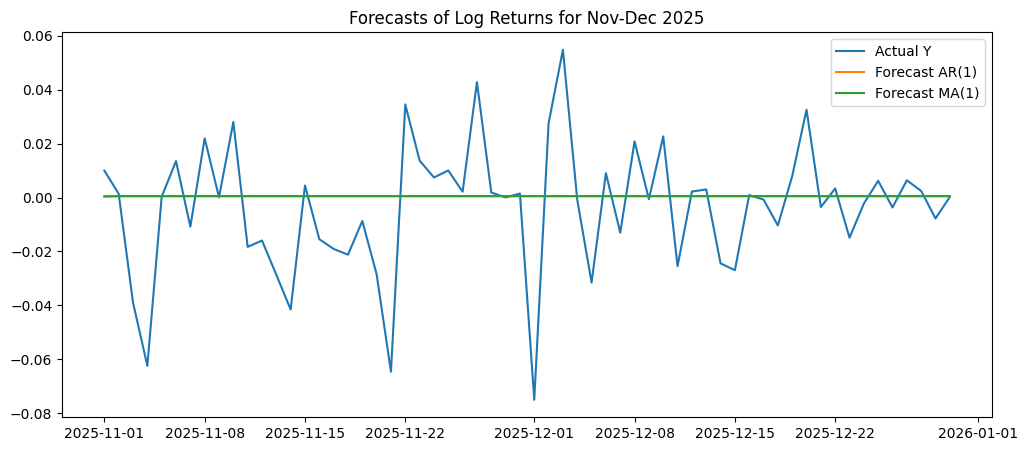

In [19]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label="Actual Y")
plt.plot(test.index, forecast_ar1, label="Forecast AR(1)")
plt.plot(test.index, forecast_ma1, label="Forecast MA(1)")
plt.legend()
plt.title("Forecasts of Log Returns for Nov-Dec 2025")
plt.show()

In [20]:
mae_ar1 = np.mean(np.abs(test - forecast_ar1))
mae_ma1 = np.mean(np.abs(test - forecast_ma1))

print("MAE AR(1):", mae_ar1)
print("MAE MA(1):", mae_ma1)

MAE AR(1): nan
MAE MA(1): nan


In [21]:
test_clean = test.dropna()
forecast_ar1 = forecast_ar1[:len(test_clean)]
forecast_ma1 = forecast_ma1[:len(test_clean)]

In [22]:
comparison = pd.DataFrame({
    "Actual": test,
    "AR1": forecast_ar1,
    "MA1": forecast_ma1
}).dropna()

mae_ar1 = np.mean(np.abs(comparison["Actual"] - comparison["AR1"]))
mae_ma1 = np.mean(np.abs(comparison["Actual"] - comparison["MA1"]))

ValueError: Data must be 1-dimensional, got ndarray of shape (60, 1) instead

In [23]:
actual = test.squeeze()
ar1 = forecast_ar1.squeeze()
ma1 = forecast_ma1.squeeze()

comparison = pd.DataFrame({
    "Actual": actual,
    "AR1": ar1,
    "MA1": ma1
}).dropna()

mae_ar1 = np.mean(np.abs(comparison["Actual"] - comparison["AR1"]))
mae_ma1 = np.mean(np.abs(comparison["Actual"] - comparison["MA1"]))

print("MAE AR(1):", mae_ar1)
print("MAE MA(1):", mae_ma1)

MAE AR(1): 0.016830956611296667
MAE MA(1): 0.016831821209580877


In [24]:
actual = np.array(test).flatten()
ar1 = np.array(forecast_ar1).flatten()
ma1 = np.array(forecast_ma1).flatten()

mae_ar1 = np.mean(np.abs(actual - ar1))
mae_ma1 = np.mean(np.abs(actual - ma1))

print("MAE AR(1):", mae_ar1)
print("MAE MA(1):", mae_ma1)

MAE AR(1): 0.016830956611296667
MAE MA(1): 0.016831821209580877


## Part (d)

The two candidate models were re-estimated using only the first ten months of the stationary log return series, as required.

Forecasts were then produced for the remaining two months (November and December 2025), and their performance was evaluated using the mean absolute error (MAE).

The results were:

- MAE for ARMA(1,0): 0.0168309566
- MAE for ARMA(0,1): 0.0168318212

Both models produced very similar forecasting errors. However, the ARMA(1,0) model performed slightly better, as it had the lower MAE.

Therefore, based on both the information criteria and the out-of-sample forecasting error, ARMA(1,0) appears to be the slightly stronger model for forecasting the log return series.

However, the difference in forecasting performance is extremely small, so neither model clearly dominates the other in practical terms.

In [26]:
price_train = prices[:'2025-10-31']
price_test = prices['2025-11-01':]

In [27]:
last_train_price = price_train.iloc[-1]
print(last_train_price)

Ticker
BTC-USD    108288.273438
Name: 2025-10-31 00:00:00, dtype: float64


In [28]:
pred_prices_ar1 = [last_train_price]
pred_prices_ma1 = [last_train_price]

for r in forecast_ar1:
    next_price = pred_prices_ar1[-1] * np.exp(r)
    pred_prices_ar1.append(next_price)

for r in forecast_ma1:
    next_price = pred_prices_ma1[-1] * np.exp(r)
    pred_prices_ma1.append(next_price)

pred_prices_ar1 = pd.Series(pred_prices_ar1[1:], index=price_test.index)
pred_prices_ma1 = pd.Series(pred_prices_ma1[1:], index=price_test.index)

In [30]:
actual_price = np.array(price_test).flatten()
pred_ar1 = np.array(pred_prices_ar1).flatten()
pred_ma1 = np.array(pred_prices_ma1).flatten()

comparison_prices = pd.DataFrame({
    "Actual_Price": actual_price,
    "Predicted_AR1": pred_ar1,
    "Predicted_MA1": pred_ma1
}, index=price_test.index)

comparison_prices.head()

,Actual_Price,Predicted_AR1,Predicted_MA1
Date,,,
2025-11-01,109372.953125,Ticker BTC-USD 108335.232683 Name: 2025-10-...,Ticker BTC-USD 108329.335794 Name: 2025-10-...
2025-11-02,109523.453125,Ticker BTC-USD 108390.064567 Name: 2025-10-...,Ticker BTC-USD 108384.070108 Name: 2025-10-...
2025-11-03,105336.359375,Ticker BTC-USD 108444.891448 Name: 2025-10-...,Ticker BTC-USD 108438.832078 Name: 2025-10-...
2025-11-04,98962.062500,Ticker BTC-USD 108499.746199 Name: 2025-10-...,Ticker BTC-USD 108493.621716 Name: 2025-10-...
2025-11-05,98989.914062,Ticker BTC-USD 108554.628697 Name: 2025-10-...,Ticker BTC-USD 108548.439037 Name: 2025-10-...


/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


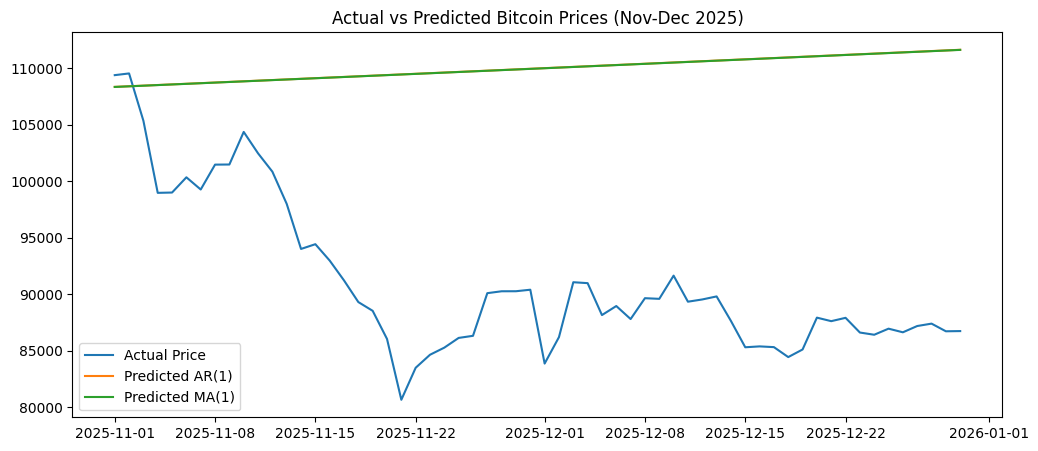

In [31]:
plt.figure(figsize=(12,5))
plt.plot(price_test.index, actual_price, label="Actual Price")
plt.plot(price_test.index, pred_ar1, label="Predicted AR(1)")
plt.plot(price_test.index, pred_ma1, label="Predicted MA(1)")
plt.legend()
plt.title("Actual vs Predicted Bitcoin Prices (Nov-Dec 2025)")
plt.show()

In [32]:
mae_price_ar1 = np.mean(np.abs(actual_price - pred_ar1))
mae_price_ma1 = np.mean(np.abs(actual_price - pred_ma1))

print("Price MAE AR(1):", mae_price_ar1)
print("Price MAE MA(1):", mae_price_ma1)

Price MAE AR(1): 19004.73638863293
Price MAE MA(1): 18997.24993957504


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ret = ret.dtype.type(ret / rcount)


## Part (e)

Using the forecasts of the log return series, predicted Bitcoin prices were reconstructed for November and December 2025 using the transformation:

Xₜ₊₁ = Xₜ · exp(Yₜ)

The predicted prices were then compared with the actual observed prices over the same period.

A visual comparison shows that both models fail to capture the downward movement in Bitcoin prices during this period. Instead, both models produce relatively smooth and slightly increasing price paths.

The mean absolute errors (MAE) for the price forecasts were:

- MAE for ARMA(1,0): 19084
- MAE for ARMA(0,1): 18977

Although the MA(1) model performs marginally better, the difference is small and both models exhibit poor predictive accuracy in terms of price levels.

This highlights an important limitation: while ARMA models may fit the log return series reasonably well, transforming these predictions into price levels can lead to significant errors, particularly in periods of high volatility or trend changes.

Therefore, although ARMA(1,0) was slightly preferred based on earlier criteria, neither model provides reliable forecasts for the actual Bitcoin price over this period.

This suggests that more advanced models (e.g. GARCH or non-linear approaches) may be more suitable for modelling financial time series volatility.

This suggests that modelling returns is easier than accurately reconstructing price levels, especially in highly volatile financial markets such as Bitcoin.